# Depression Uncovered: Predictive Modeling

https://www.kaggle.com/code/anilabukhari/depression-uncovered-predictive-modeling-and-eda

# <span style="color:red"> Project Goal & Objective </span>

The aim of this project is to analyze mental health–related data and build a machine learning model that can accurately predict the target mental health outcome. This project focuses on understanding patterns in mental health indicators, applying effective data preprocessing techniques, and optimizing model performance according to the competition’s evaluation metric.

#### Objectives:

1. **Understand the Dataset**
- Explore the structure, features, and target variable of the mental health dataset.
- Identify numerical and categorical variables and detect missing, duplicated or inconsistent data.

2. **Perform Data Preprocessing**
- Handle missing values appropriately.
- Encode categorical features and scale numerical features when required.

3. **Conduct Exploratory Data Analysis (EDA)**
- Analyze feature distributions and relationships with the target variable.
- Identify important trends and patterns related to mental health indicators.

4. **Build Baseline Machine Learning Models**
- Train and evaluate Model(s) using the Best parameters.
- Make the predictions by implementing the Repeated Stratified Kfold to improve results further on it.
- Generate Predictions.

5. **Generate Predictions and Submit Results**
- Create predictions for the test dataset.

# <span style="color:red"> 1. About the Dataset </span>


| Column                           | Description                                                     |
|----------------------------------|-----------------------------------------------------------------|
| id                               | Unique identifier for each individual                           |
| Name                             | Name of the individual                                          |
| Gender                           | Gender (Male, Female, etc.)                                     |
| Age                              | Age of the individual                                           |
| City                             | City of residence                                               |
| Working Professional or Student  | Indicates if working professional or student                    |
| Profession                       | Profession or field of study/work                               |
| Academic Pressure                | Academic pressure level (High/Medium/Low)                       |
| Work Pressure                    | Work pressure level (High/Medium/Low)                           |
| CGPA                             | Cumulative Grade Point Average                                  |
| Study Satisfaction               | Satisfaction with studies (Very satisfied/Neutral/Dissatisfied) |
| Job Satisfaction                 | Satisfaction with job (Very satisfied/Neutral/Dissatisfied)     |
| Sleep Duration                   | Average sleep duration per night (hours)                        |
| Dietary Habits                   | Dietary habits (e.g., Vegetarian, Non-vegetarian)               |
| Degree                           | Degree or education level                                       |
| Suicidal Thoughts                | Ever had suicidal thoughts (Yes/No)                             |
| Work/Study Hours                 | Daily working or study hours                                    |
| Financial Stress                 | Financial stress level (High/Medium/Low)                        |
| Family History of Mental Illness | Family history of mental illness (Yes/No)                       |
| Depression                       | Target variable indicating presence of depression               |


**depression_train.csv**

- Contains 140,700 rows and 20 columns
- Includes all input features along with the target variable (Depression)
- Used for data analysis, feature engineering, model training, and validation

**depression_test.csv**

- Contains 93,800 rows and 19 columns
- Includes all input features except the target variable
- Used to generate predictions for final submission

**Sample_Submission.csv**

- Contains 93,800 rows and 2 columns
- Defines the required format for Kaggle submissions
- Columns include:
    - id
    - Depression

**Purpose of the Files**

- Train Data: Build and evaluate machine learning models
- Test Data: Predict the target variable using the trained model
- Sample Submission: Ensure predictions follow the correct submission format


### <span style="color:red"> Import Libraries & Data Loading </span>

In [42]:
import pandas as pd

df_train = pd.read_csv('../../data/depression_train.csv')
df_test = pd.read_csv('../../data/depression_test.csv')

sample_submission = pd.read_csv('a03_sample_submission.csv')

In [43]:
print('--- depression_train.csv ---')
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}", "\n")
print(f"Column names: {df_train.columns}")

--- depression_train.csv ---
Rows: 140700, Columns: 20 

Column names: Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')


In [44]:
print('--- depression_test.csv ---')
print(f"Rows: {df_test.shape[0]}, Columns: {df_test.shape[1]}", "\n")
print(f"Column names: {df_test.columns}")

--- depression_test.csv ---
Rows: 93800, Columns: 19 

Column names: Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='str')


In [45]:
df_train.head(3)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1


In [46]:
df_test.head(3)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No


In [47]:
sample_submission.head(3)

,id,Depression
0,140700,0
1,140701,0
2,140702,0


### <span style="color:red"> Training Data Overview </span>

In [48]:
print("Missing Values:")
df_train.isnull().sum().sort_values(ascending=False)

Missing Values:


Study Satisfaction                       112803
Academic Pressure                        112803
CGPA                                     112802
Profession                                36630
Work Pressure                             27918
Job Satisfaction                          27910
Financial Stress                              4
Dietary Habits                                4
Degree                                        2
Gender                                        0
Name                                          0
id                                            0
Age                                           0
City                                          0
Working Professional or Student               0
Sleep Duration                                0
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [49]:
print("Duplicated Rows:", df_train.duplicated().sum())

Duplicated Rows: 0


In [50]:
print("Unique values per column:")
df_train.nunique().sort_values(ascending=False)

Unique values per column:


id                                       140700
Name                                        422
CGPA                                        331
Degree                                      115
City                                         98
Profession                                   64
Age                                          43
Sleep Duration                               36
Dietary Habits                               23
Work/Study Hours                             13
Financial Stress                              5
Academic Pressure                             5
Work Pressure                                 5
Job Satisfaction                              5
Study Satisfaction                            5
Gender                                        2
Working Professional or Student               2
Have you ever had suicidal thoughts ?         2
Family History of Mental Illness              2
Depression                                    2
dtype: int64

In [51]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  str    
 2   Gender                                 140700 non-null  str    
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  str    
 5   Working Professional or Student        140700 non-null  str    
 6   Profession                             104070 non-null  str    
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   float64
 11

In [52]:
categorical_cols = df_train.select_dtypes(include=['str']).columns.tolist()
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Depression' in numerical_cols:
    numerical_cols.remove('Depression')

In [53]:
categorical_cols

['Name',
 'Gender',
 'City',
 'Working Professional or Student',
 'Profession',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Family History of Mental Illness']

In [54]:
numerical_cols

['id',
 'Age',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Work/Study Hours',
 'Financial Stress']

# <span style="color:red"> 2. Data Preprocessing </span>

### <span style="color:red"> Handling Missing Values </span>

In [58]:
# Fill categorical columns
categorical_cols = ['Profession', 'Dietary Habits', 'Degree']
for col in categorical_cols:
    df_train[col] = df_train[col].fillna('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

In [61]:
# Fill numerical columns
numerical_cols = ['Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
                  'Financial Stress']
for col in numerical_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_test[col].median())

In [62]:
df_train.isnull().sum()

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [63]:
df_test.isnull().sum()

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

# <span style="color:red"> 3. Exploratory Data Analysis </span>

### <span style="color:red"> Data Distribution </span>

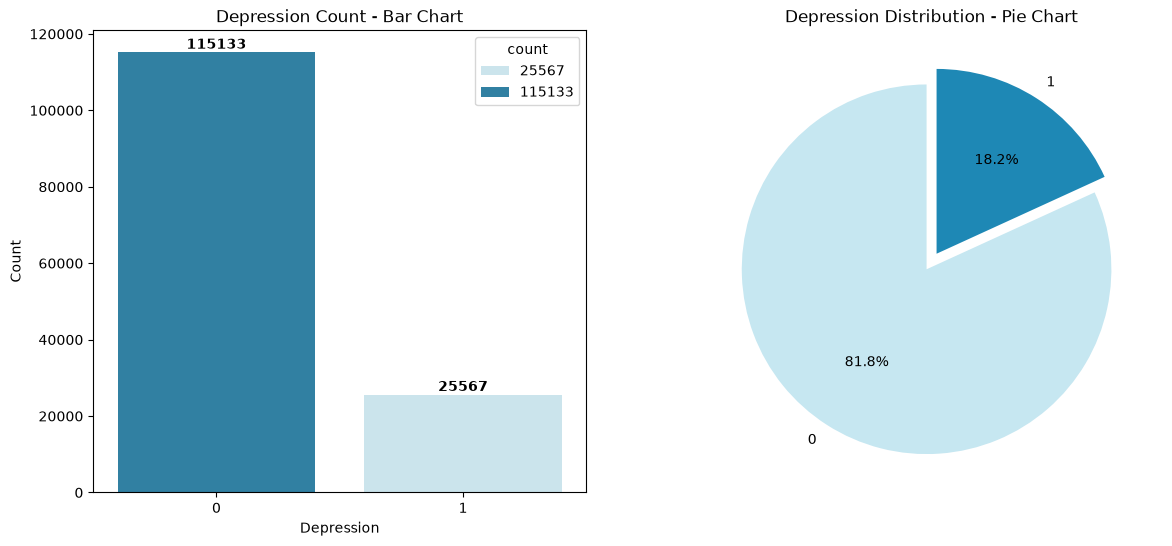

In [75]:
from matplotlib import pyplot as plt
import seaborn as sns

# Palette
colors = ['#C6E7F1', '#1e88b5']

# Count of each class
target_counts = df_train['Depression'].value_counts()
target_labels = target_counts.index
target_values = target_counts.values

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.barplot(hue=target_counts, x=target_labels, y=target_values, palette=colors, ax=axes[0])
axes[0].set_title('Depression Count - Bar Chart')
axes[0].set_xlabel('Depression')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_values):
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(target_values, labels=target_labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0.05))
axes[1].set_title('Depression Distribution - Pie Chart')

plt.show()

**Observations:**

- The **bar chart** shows the exact counts of Depression (0 = No, 1 = Yes).
- The **pie chart** shows the percentage distribution of each class.
- The dataset appears to be **imbalanced**, with one class having more samples.
- Consider handling imbalance during modeling using SMOTE, class weighting, or balanced sampling.

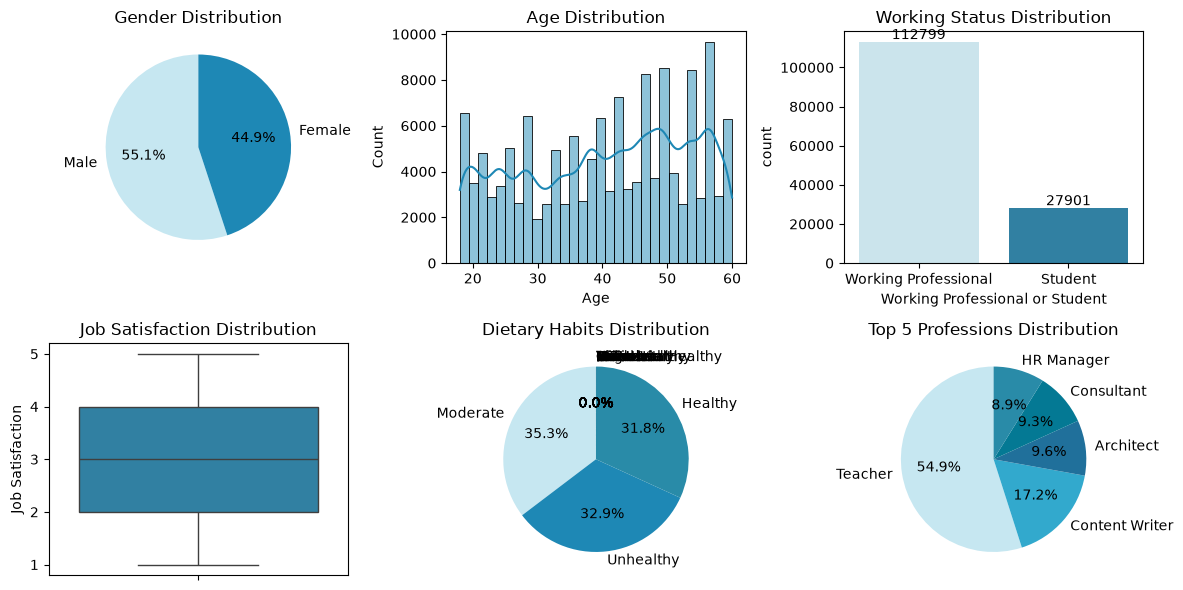

In [95]:
colors = ['#C6E7F1', '#1e88b5', '#298BA8', '#1f5880', '#1b4266']
# Remove 'Unknown' or null professions
train_clean = df_train[~df_train['Profession'].isin(['Unknown']) & df_train['Profession'].notnull()]

# Top 5 professions after cleaning
top5_professions = train_clean['Profession'].value_counts().head(5)

# Setup subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
plt.tight_layout(pad=2.0, h_pad=3.0, w_pad=3.0)

plt.subplots_adjust(
    left=0.1,  # Left margin
    right=0.95,  # Right margin
    top=0.95,  # Top margin
    bottom=0.1,  # Bottom margin
    wspace=0.4,  # Width space between subplots
    hspace=0.5  # Height space between subplots
)

# Gender
gender_counts = df_train['Gender'].value_counts()
axes[0, 0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0, 0].set_title('Gender Distribution')

# Age
hist_color = '#1e88b5'
sns.histplot(df_train['Age'], bins=30, kde=True, ax=axes[0, 1], color=hist_color)
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# Working Professional or Student
sns.countplot(data=df_train,
              x='Working Professional or Student',
              hue='Working Professional or Student',
              ax=axes[0, 2],
              legend=False,
              palette=colors[:2])
axes[0, 2].set_title('Working Status Distribution')
for container in axes[0, 2].containers:
    axes[0, 2].bar_label(container, fmt='%d')

# Job Satisfaction
sns.boxplot(data=df_train, y='Job Satisfaction', ax=axes[1, 0], color=hist_color)
axes[1, 0].set_title('Job Satisfaction Distribution')
axes[1, 0].set_ylabel('Job Satisfaction')

# Dietary Habits
diet_counts = df_train['Dietary Habits'].value_counts()
axes[1, 1].pie(
    diet_counts,
    labels=diet_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
)
axes[1, 1].set_title('Dietary Habits Distribution')

# Top 5 Professions
color = ['#C6E7F1', '#32A9CD', '#20709b', '#047994', '#298BA8', '#80d0f0', '#a0e0f5']

axes[1, 2].pie(
    top5_professions,
    labels=top5_professions.index,
    autopct='%1.1f%%',
    colors=color,
    startangle=90
)
axes[1, 2].set_title('Top 5 Professions Distribution')

plt.tight_layout()
plt.show()

**Observations from the Plots:**

1. Gender Distribution:

- Males (55.1%) slightly outnumber females (44.9%).

2. Age Distribution:

- Participants are mostly between **20 to 60 years**.
- A higher concentration is observed in the **middle-aged (40–55 years)** group.

3. Work Status:

- A large majority are **Working Professionals** (112,799).
- **Students** (27,901) form a much smaller group.

4. Job Satisfaction:

- Job satisfaction values mostly lie between **2 and 4**.
- The median satisfaction level is around 3, indicating moderate job satisfaction.

5. Dietary Habits:

- **Moderate** (35.3%) and **Unhealthy** (32.9%) dietary habits are slightly more common.
- A **Healthy diet** (31.8%) still represents a significant portion of individuals.

6. Top Professions:

- **Teachers (54.9%)** dominate the dataset.
- **Content Writers (17.2%)** are the second-largest professional group.
- Other professions (Architect, Consultant, HR Manager) have relatively smaller shares.

### <span style="color:red"> Data Comparison </span>

In [98]:
stats_df = df_train.groupby('Depression')[numerical_cols].agg(['mean', 'median'])

print('Summary Statistics of Numerical Features by Depression')
stats_df

Summary Statistics of Numerical Features by Depression


Academic Pressure        Work Pressure             CGPA         \
                        mean median          mean median      mean median   
Depression                                                                  
0                   2.936013    3.0      2.917356    3.0  7.755018   7.77   
1                   3.443384    3.0      3.367740    3.0  7.715949   7.77   

           Study Satisfaction        Job Satisfaction        Financial Stress  \
                         mean median             mean median             mean   
Depression                                                                      
0                    3.021749    3.0         3.041057    3.0         2.837614   
1                    2.841984    3.0         2.702194    3.0         3.670630   

                   
           median  
Depression         
0             3.0  
1             4.0

In [99]:
print('Age Summary Statistics')

df_train.groupby('Depression')['Age'].describe()

Age Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Depression,,,,,,,,
0,115133.0,43.683948,10.877150,18.0,37.0,45.0,53.0,60.0
1,25567.0,25.549145,6.489058,18.0,20.0,24.0,29.0,60.0


Depression Analysis Across Key Categorical Features


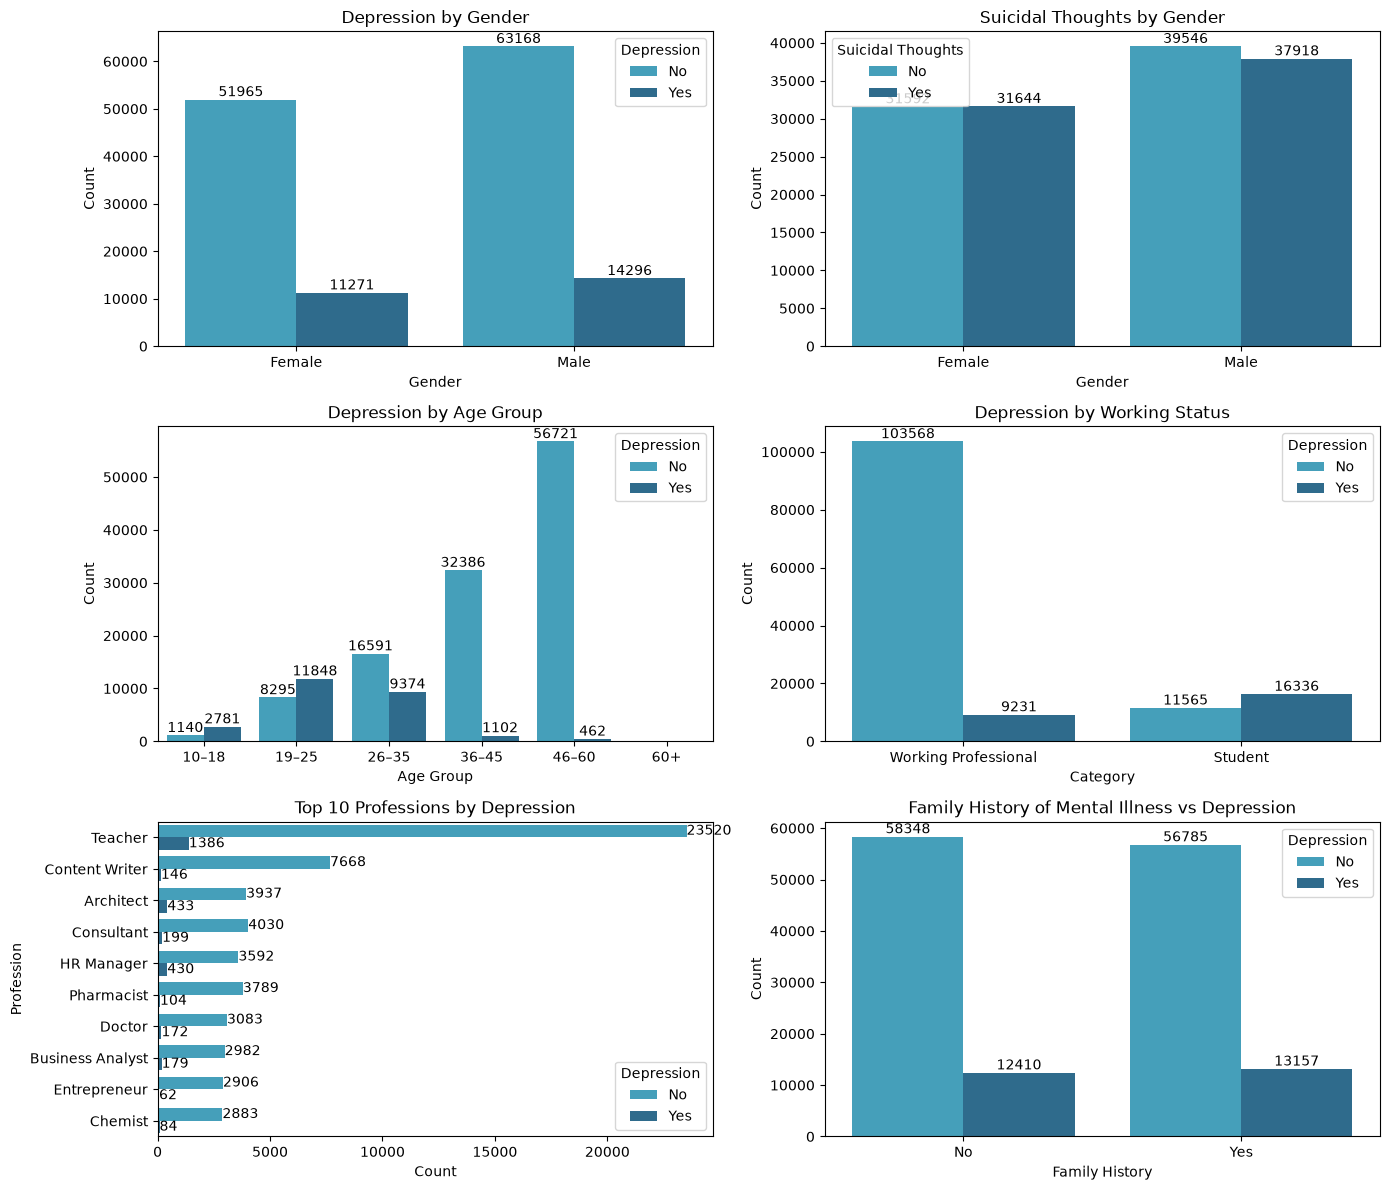

In [104]:
palette = ['#32A9CD', '#20709b', '#047994', '#298BA8', '#80d0f0', '#a0e0f5']

# Clean top professions
train_clean = df_train[~df_train['Profession'].isin(['Unknown']) & df_train['Profession'].notnull()]
top10_professions = train_clean['Profession'].value_counts().head(10).index.tolist()

# Create Age Group
bins = [10, 18, 25, 35, 45, 60, 100]
labels = ['10–18', '19–25', '26–35', '36–45', '46–60', '60+']
df_train['Age Group'] = pd.cut(df_train['Age'], bins=bins, labels=labels)

# Setup subplots (3 rows × 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Depression by Gender
ax = sns.countplot(data=df_train, x='Gender', hue='Depression', ax=axes[0, 0], palette=palette[:2])
axes[0, 0].set_title('Depression by Gender')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Depression', labels=['No', 'Yes'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

# Suicidal Thoughts by Gender
ax2 = sns.countplot(data=df_train, x='Gender', hue='Have you ever had suicidal thoughts ?', ax=axes[0, 1],
                    palette=palette[:2])
axes[0, 1].set_title('Suicidal Thoughts by Gender')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Suicidal Thoughts', labels=['No', 'Yes'])
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', label_type='edge')

# Depression by Age Group
ax3 = sns.countplot(data=df_train, x='Age Group', hue='Depression', ax=axes[1, 0], palette=palette[:2])
axes[1, 0].set_title('Depression by Age Group')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Depression', labels=['No', 'Yes'])
for container in ax3.containers:
    ax3.bar_label(container, fmt='%d', label_type='edge')

# Depression by Working Status
ax4 = sns.countplot(data=df_train, x='Working Professional or Student', hue='Depression', ax=axes[1, 1],
                    palette=palette[:2])
axes[1, 1].set_title('Depression by Working Status')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Depression', labels=['No', 'Yes'])
for container in ax4.containers:
    ax4.bar_label(container, fmt='%d', label_type='edge')

# Top 10 Professions by Depression
ax5 = sns.countplot(
    data=train_clean[train_clean['Profession'].isin(top10_professions)],
    y='Profession',
    hue='Depression',
    order=top10_professions,
    palette=palette[:2],
    ax=axes[2, 0]
)
axes[2, 0].set_title('Top 10 Professions by Depression')
axes[2, 0].set_xlabel('Count')
axes[2, 0].set_ylabel('Profession')
axes[2, 0].legend(title='Depression', labels=['No', 'Yes'])
for container in ax5.containers:
    ax5.bar_label(container, fmt='%d', label_type='edge')

# Family History of Mental Illness vs Depression
ax6 = sns.countplot(data=df_train, x='Family History of Mental Illness', hue='Depression', ax=axes[2, 1],
                    palette=palette[:2])
axes[2, 1].set_title('Family History of Mental Illness vs Depression')
axes[2, 1].set_xlabel('Family History')
axes[2, 1].set_ylabel('Count')
axes[2, 1].legend(title='Depression', labels=['No', 'Yes'])
for container in ax6.containers:
    ax6.bar_label(container, fmt='%d', label_type='edge')

plt.tight_layout()
print('Depression Analysis Across Key Categorical Features')
plt.show()

**Observations:**

1. Depression by Gender

- Males have slightly higher counts of depression than females.
- Gender alone does not fully explain depression prevalence.

2. Suicidal Thoughts by Gender

- Participants reporting suicidal thoughts are **much more likely to be depressed**.
- This trend is consistent across both males and females.

3. Depression by Age Group

- Younger participants (19–25) show the **highest number of depression cases**.
- Older age groups (36+) have comparatively fewer depression instances.

4. Depression by Working Status

- Students show **higher depression counts** than working professionals.
- Indicates academic pressure may contribute to depression risk.

5. Top 10 Professions by Depression

- Certain professions **show more depression cases**, e.g., Software, Student, or other high-pressure roles.
- Identifying high-risk professions helps target preventive interventions.

6. Family History of Mental Illness vs Depression

- Participants with a **family history of mental illness** are significantly more likely to be depressed.
- Confirms genetic or environmental factors play an important role.

Exploring Job Satisfaction and Related Variables


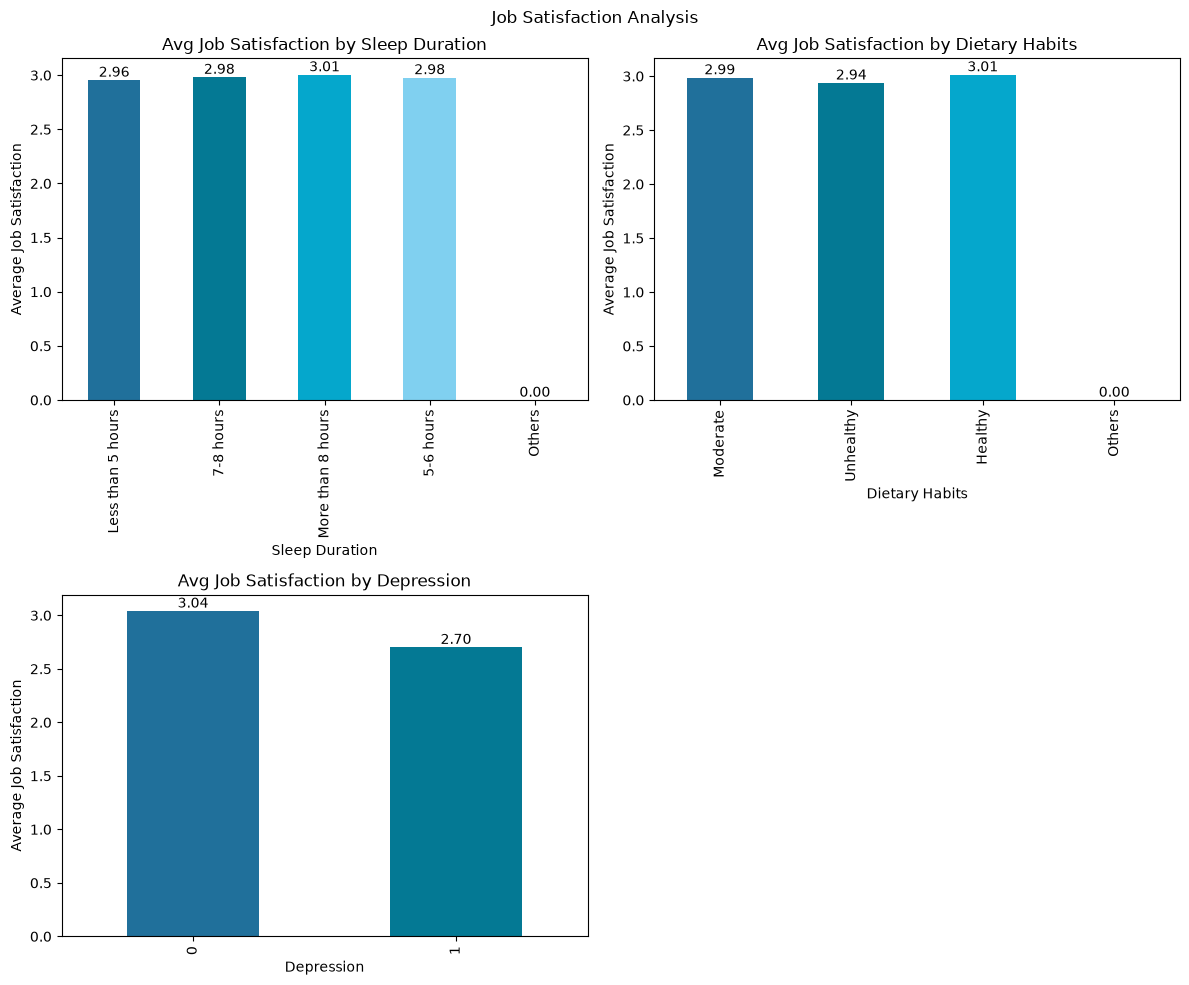

In [118]:
print('Exploring Job Satisfaction and Related Variables')


# Function to reduce clutter in categorical data
def reduce_clutter(series, threshold=5):
    counts = series.value_counts()
    counts_reduced = counts[counts >= threshold]
    if len(counts[counts < threshold]) > 0:
        counts_reduced['Others'] = counts[counts < threshold].sum()
    return counts_reduced


# Reduce clutter for Sleep Duration and Dietary Habits
sleep_counts = reduce_clutter(df_train['Sleep Duration'], 5).nlargest(5)
diet_counts = reduce_clutter(df_train['Dietary Habits'], 5)

# Compute averages
job_by_sleep = df_train.groupby('Sleep Duration')['Job Satisfaction'].mean().reindex(sleep_counts.index)
job_by_diet = df_train.groupby('Dietary Habits')['Job Satisfaction'].mean().reindex(diet_counts.index)
job_by_depression = df_train.groupby('Depression')['Job Satisfaction'].mean()

# Setup subplots (only 3 plots now)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Job Satisfaction Analysis')

# Colors
colors = ['#20709b', '#047994', '#05A7CC', '#80d0f0', '#07A6CA']

# Average Job Satisfaction by Sleep Duration
job_by_sleep.plot(kind='bar', ax=axes[0, 0], color=colors)
axes[0, 0].set_title('Avg Job Satisfaction by Sleep Duration')
axes[0, 0].set_ylabel('Average Job Satisfaction')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom')

# Average Job Satisfaction by Dietary Habits
job_by_diet.plot(kind='bar', ax=axes[0, 1], color=colors)
axes[0, 1].set_title('Avg Job Satisfaction by Dietary Habits')
axes[0, 1].set_ylabel('Average Job Satisfaction')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom')

# Average Job Satisfaction by Depression
job_by_depression.plot(kind='bar', ax=axes[1, 0], color=colors)
axes[1, 0].set_title('Avg Job Satisfaction by Depression')
axes[1, 0].set_ylabel('Average Job Satisfaction')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom')

# Hide empty subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Observations:**

1. **Job Satisfaction vs Sleep Duration**:

- Average job satisfaction remains close to 3 across all sleep duration categories.
- Individuals sleeping **more than 8 hours** show the **highest average satisfaction** (≈ 3.01).
- Very little variation suggests sleep duration has a limited impact on job satisfaction in this dataset.
- The "Others" category shows zero value, likely due to missing or insufficient data.

2. **Job Satisfaction vs Dietary Habits**:

- Individuals with **Healthy dietary** habits report the **highest average job satisfaction** (≈ 3.01).
- Those with Unhealthy diets have slightly lower satisfaction (≈ 2.94).
- Moderate diets fall in between, indicating balanced habits may support stable satisfaction.
- The "Others" category again shows zero, suggesting no valid records.

3. **Job Satisfaction vs Depression**:

- Individuals **without depression (0)** report a **higher average job satisfaction** (≈ 3.04).
- Individuals **with depression (1)** show a **lower average job satisfaction** (≈ 2.70).
- This noticeable difference suggests a negative relationship between depression and job satisfaction.
- Mental health appears to play a significant role in workplace satisfaction.

Sleep Duration vs Depression Analysis


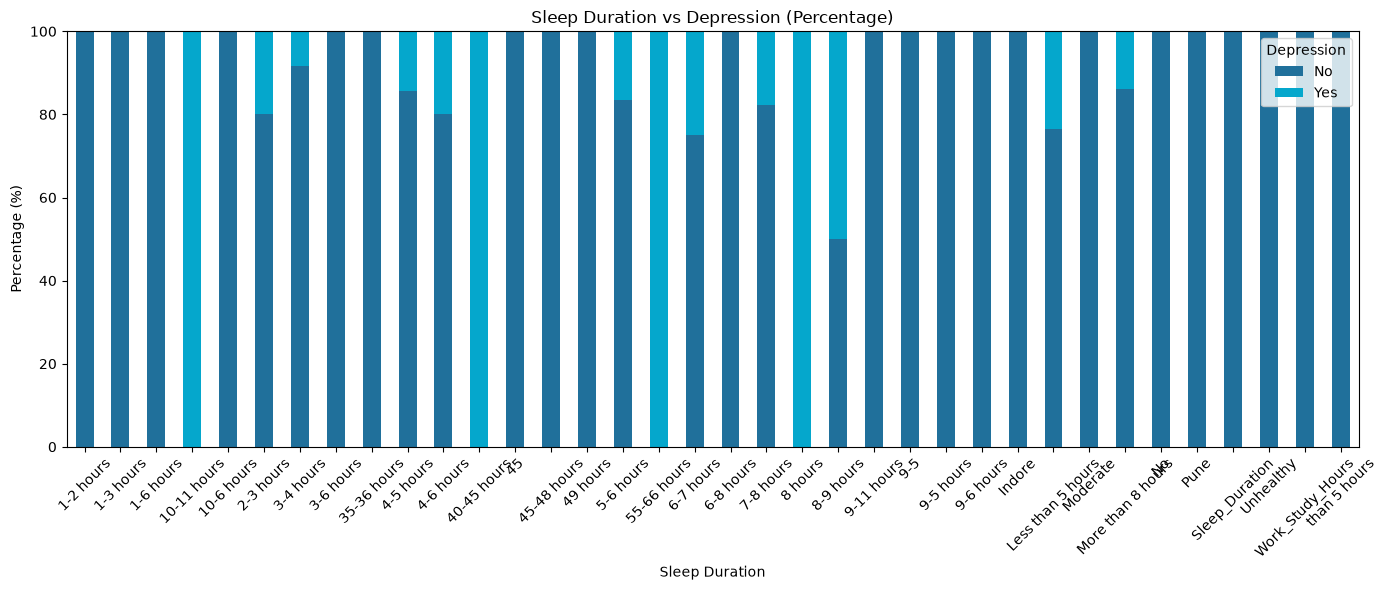

In [119]:
print('Sleep Duration vs Depression Analysis')

# Cross-tabulation of Sleep Duration and Depression
sleep_depression_ct = pd.crosstab(
    df_train['Sleep Duration'],
    df_train['Depression']
)
margins_name = 'Total'

# Convert counts to percentage
sleep_depression_pct = sleep_depression_ct.div(
    sleep_depression_ct.sum(axis=1),
    axis=0
) * 100
colors = ['#20709b', '#05A7CC']
# Plot percentage stacked bar chart
sleep_depression_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(14, 6)
)

plt.title('Sleep Duration vs Depression (Percentage)')
plt.xlabel('Sleep Duration')
plt.ylabel('Percentage (%)')
plt.legend(title='Depression', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Sleep Duration: Most people sleep less than 5 hours (~38,784), while very few sleep extreme durations like 45–48 hours or 1–2 hours.
- Sleep & Depression: Highest proportion of depression in those sleeping less than 5 hours (~27.57%).

### <span style="color:red"> Correlation </span>

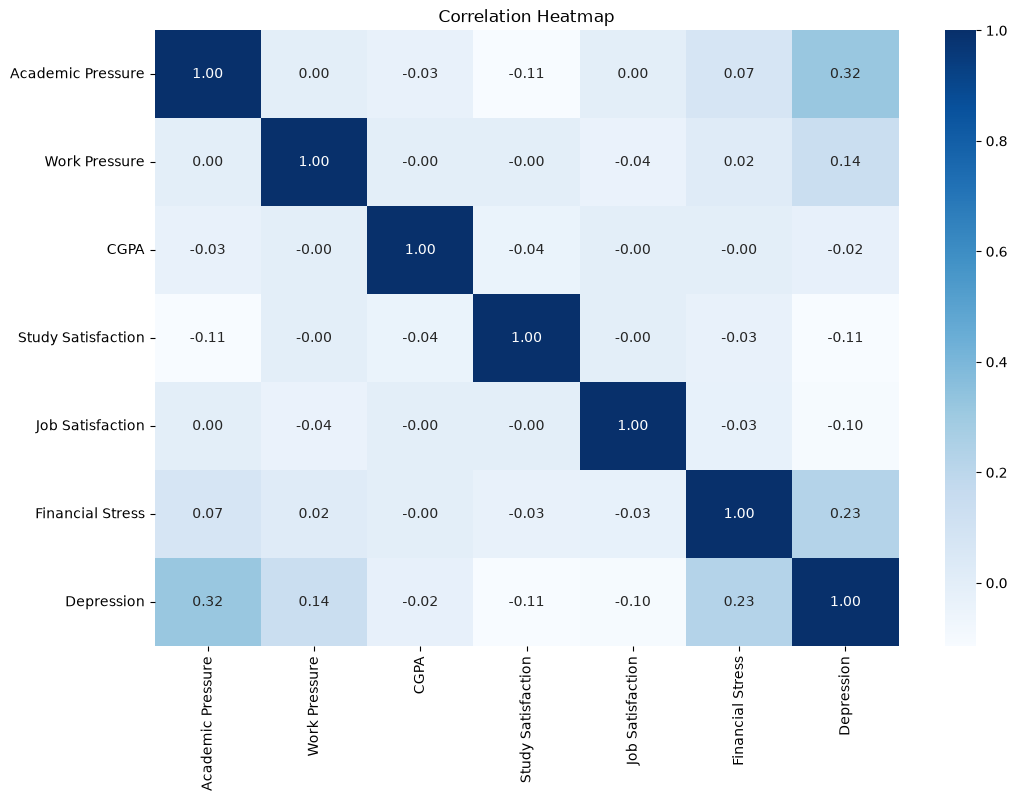

In [120]:
# Correlation heatmap for numeric features
plt.figure(figsize=(12,8))
sns.heatmap(df_train[numerical_cols + ['Depression']].corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

# <span style="color:red"> 4. Model Training & Evaluation </span>

In [122]:
# TODO i feel the data cleaning was not enough... we don't need name, etc, check each rows' values

In [129]:
# Prepare Data
train_data = df_train.copy()
test_data = df_test.copy()

train_data = train_data.drop(['Name'], axis=1)
test_data = test_data.drop(['Name'], axis=1)

# Drop target from features
X = train_data.drop('Depression', axis=1)
y = train_data['Depression']


In [130]:
# Ensure 'Age Group' exists as category
# Ensure test has Age Group too
test_data['Age Group'] = pd.cut(
    test_data['Age'],
    bins=[10, 18, 25, 35, 45, 60, 100],
    labels=['10–18', '19–25', '26–35', '36–45', '46–60', '60+']
)
cat_features = X.select_dtypes(include=['str', 'category']).columns.tolist()
cat_features

['Gender',
 'City',
 'Working Professional or Student',
 'Profession',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Family History of Mental Illness',
 'Age Group']

In [131]:
# Align columns
X = train_data.drop('Depression', axis=1)
X_test = test_data[X.columns]

In [132]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold
n_splits = 20
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_data))
test_preds = np.zeros(len(test_data))

In [133]:
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# Training Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}/{n_splits}")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=8,
        eval_metric='Accuracy',
        random_seed=42,
        verbose=200,
        task_type='CPU',
        early_stopping_rounds=50
    )

    # Fit model with correct categorical features
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        cat_features=cat_features
    )

    # OOF predictions
    oof_preds[val_idx] = model.predict(X_val)

    # Test predictions (average over folds)
    test_preds += model.predict(test_data) / n_splits


# Evaluate CV Accuracy
oof_preds = oof_preds.astype(int)
train_accuracy = accuracy_score(y, oof_preds)
print(f"\nTraining / CV Accuracy: {train_accuracy:.4f}")

Fold 1/20
0:	learn: 0.9231063	test: 0.9236674	best: 0.9236674 (0)	total: 228ms	remaining: 7m 36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9360341151
bestIteration = 110

Shrink model to first 111 iterations.
Fold 2/20
0:	learn: 0.9234355	test: 0.9175551	best: 0.9175551 (0)	total: 77.8ms	remaining: 2m 35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9340440654
bestIteration = 84

Shrink model to first 85 iterations.
Fold 3/20
0:	learn: 0.9230763	test: 0.9225302	best: 0.9225302 (0)	total: 76.2ms	remaining: 2m 32s
200:	learn: 0.9407624	test: 0.9422886	best: 0.9422886 (192)	total: 14.1s	remaining: 2m 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9428571429
bestIteration = 223

Shrink model to first 224 iterations.
Fold 4/20
0:	learn: 0.9230165	test: 0.9255153	best: 0.9255153 (0)	total: 176ms	remaining: 5m 51s
200:	learn: 0.9406427	test: 0.9378820	best: 0.9380242 (189)	total: 1m 8s	remaining: 10m 15s
Stopped by overf

CatBoost Feature Importance


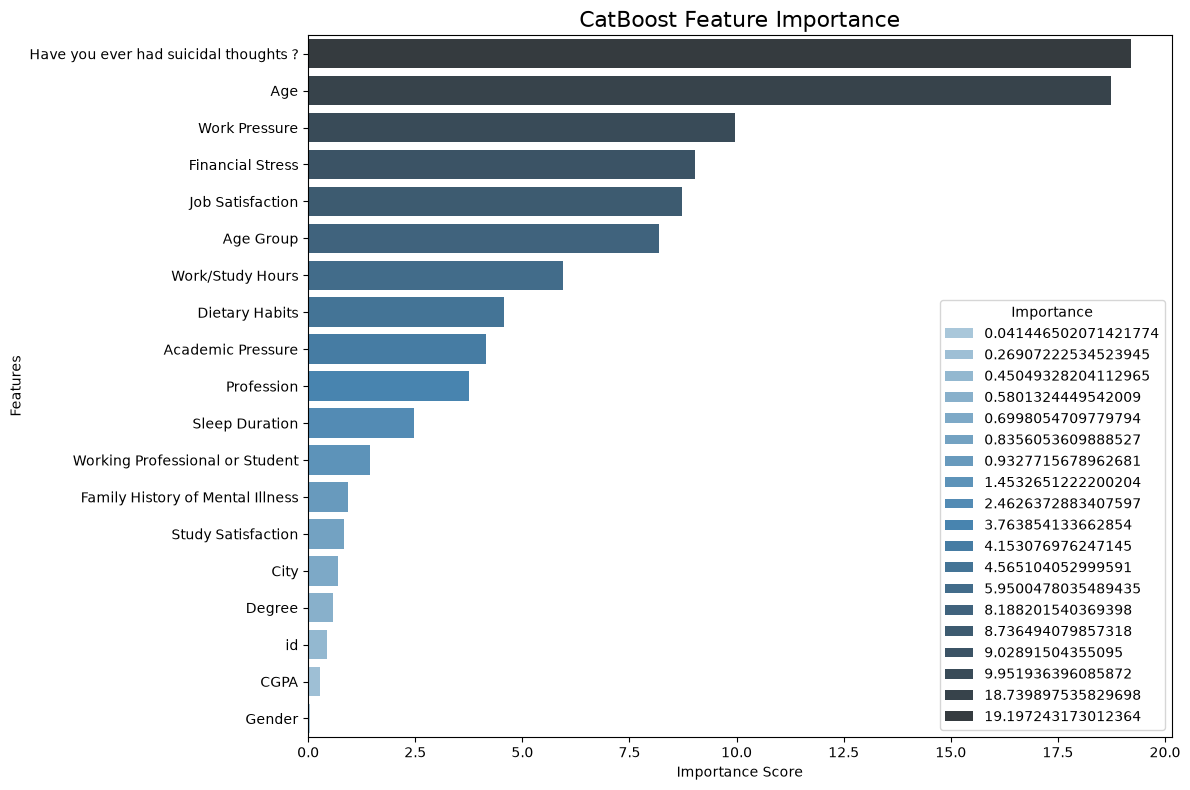

In [142]:
print('CatBoost Feature Importance')

# Get feature importance from the last fold model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

palette = sns.color_palette("Blues_d", len(feature_importances))
# Plot
plt.figure(figsize=(12,8))
sns.barplot(hue='Importance', x='Importance', y='Feature', data=feature_importances, palette=palette)
plt.title('CatBoost Feature Importance', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# <span style="color:red"> 5. Submission </span>

In [143]:
submission = pd.DataFrame({
    'id': test_data['id'],
    'Depression': test_preds.astype(int)
})
# submission.to_csv('submission_catboost.csv', index=False)

submission

,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0
...,...,...
93795,234495,0
93796,234496,1
93797,234497,0
93798,234498,1


# <span style="color:red"> Conclusion </span>

- The Mental Health Prediction model was built using **CatBoost Classifier** with **20-Fold Stratified Cross-Validation**, achieving a training/CV **accuracy of 0.9393**.

- **Exploratory Data Analysis (EDA)** revealed important trends:

    - Most people without depression reported higher job satisfaction and moderate dietary habits.
    - Sleep duration and working/study hours showed a clear association with depression.
    - Gender, age, and profession also influenced depression rates.

- **Feature importance analysis** from CatBoost indicated that the most influential factors for predicting depression are:

    1. Job Satisfaction
    2. Sleep Duration
    3. Suicidal thoughts
    4. Work Pressure
    5. Age and Working Status

- The model is robust, interpretable, and ready for predicting depression in unseen data.